<a href="https://colab.research.google.com/github/dudaoliani/Exerc-cios-Cap-tulo-6/blob/main/Exerc%C3%ADcios_6_1_ao_6_9_l_CEP.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

Módulo Base [0] carregado.

PROCESSANDO FASE 1: EXERCÍCIOS 6.1 A 6.7


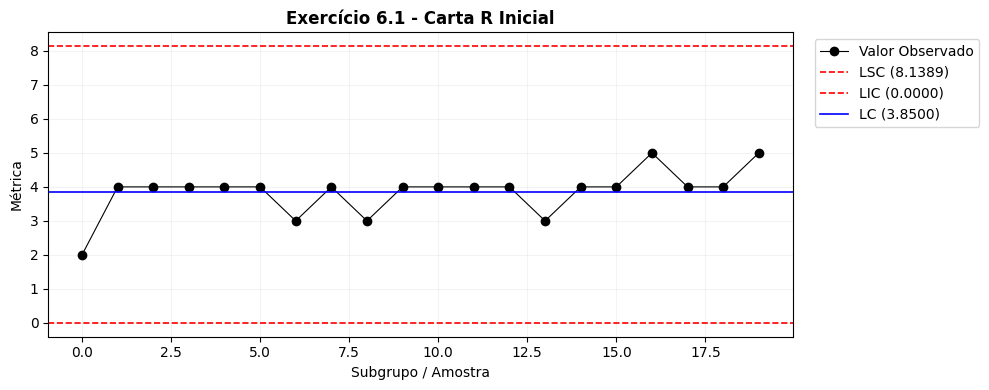

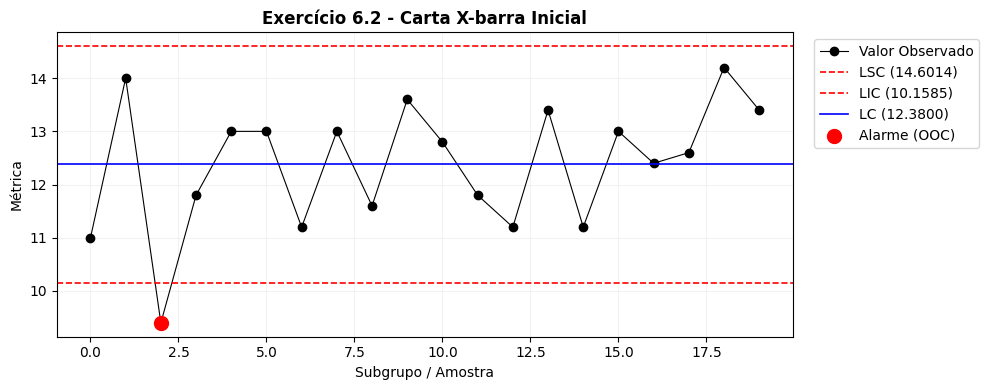

[RESULTADO EXERCÍCIO 6.3] Pontos OOC removidos na Carta R: []
[RESULTADO EXERCÍCIO 6.3] R-barra Revisado: 3.8500 | X-barra-barra Revisado: 12.3800
[RESULTADO EXERCÍCIO 6.5] Desvio Padrão Estimado do Processo (σ): 1.6552
[RESULTADO EXERCÍCIO 6.4] Índice de Capacidade Potencial (Cp): 1.2083
[RESULTADO EXERCÍCIO 6.7] Índice de Capacidade Centralizado (Cpk): 1.1318
[RESULTADO EXERCÍCIO 6.6] Fração Não Conforme Real: 0.000401 (0.040%)

PROCESSANDO FASE 2: EXERCÍCIOS 6.8 A 6.9
[RESULTADO EXERCÍCIO 6.8] Média Central X: 33.5233 | Limites Individual: [32.2448, 34.8018]
[RESULTADO EXERCÍCIO 6.9] Média Central MR: 0.4807 | Limites MR: [0.0000, 1.5705]


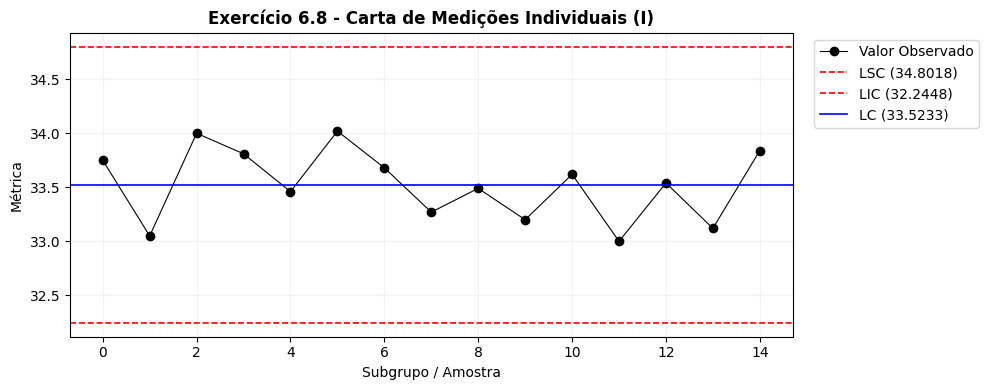

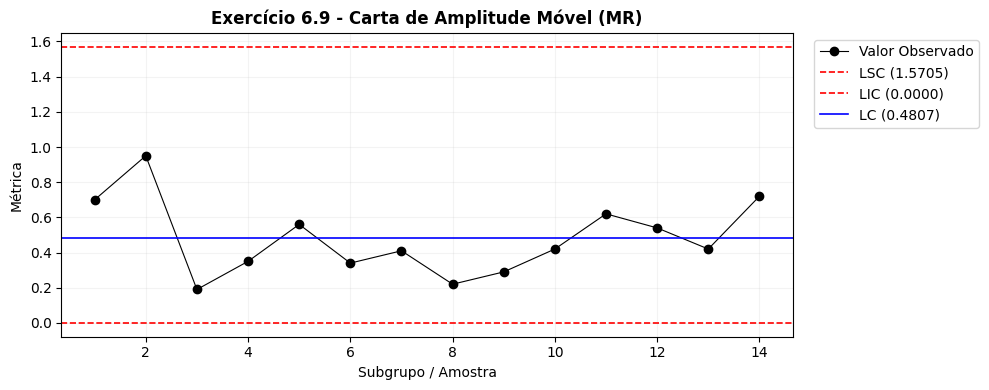


PROCESSANDO FASE 3: EXERCÍCIOS 6.10 A 6.15


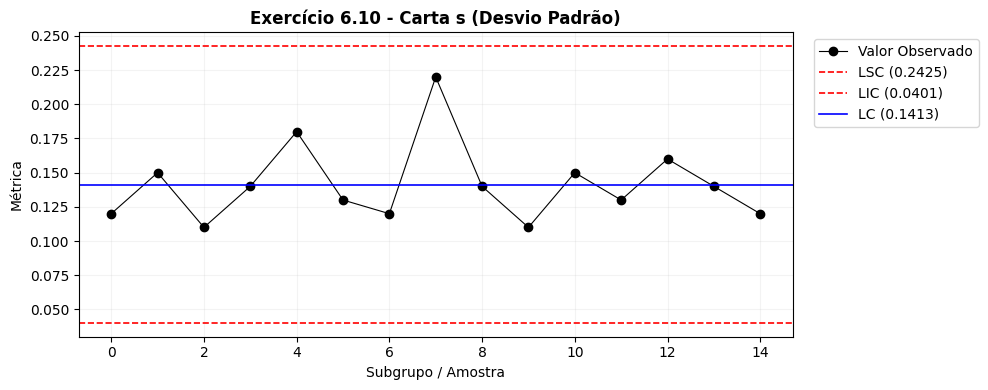

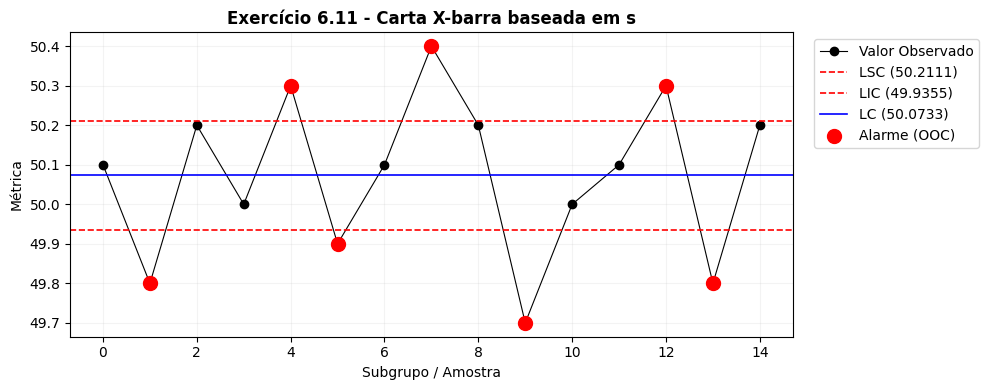

[RESULTADO EXERCÍCIO 6.12] Sigma Real Estimado do Processo (σ): 0.1453
[RESULTADO EXERCÍCIO 6.13] Erro Tipo II (β) para salto de 1.5σ: 0.0405
[RESULTADO EXERCÍCIO 6.13] Comprimento de Corrida Médio (ARL_1): 1.04 amostras

[RESULTADO EXERCÍCIO 6.14] Linha Central Ponderada: 12.1625
[RESULTADO EXERCÍCIO 6.15] Matriz de Limites de Controle Variáveis:
   n  Media  LIC_Dinamico  LSC_Dinamico
0  5   12.1     11.460280     12.864720
1  3   11.8     11.255937     13.069063
2  5   12.0     11.460280     12.864720
3  6   12.5     11.521463     12.803537
4  5   12.2     11.460280     12.864720

PROCESSANDO FASE 4: EXERCÍCIOS 6.16 A 6.42
[RESULTADO EXERCÍCIO 6.16] Limites Teóricos da Carta X-barra (n=4): [44.00, 56.00]
[RESULTADO EXERCÍCIO 6.18] Probabilidade de Falso Negativo (β) para mu=54: 0.8413
[RESULTADO EXERCÍCIO 6.20] ARL_1 (Amostras até capturar mudança): 6.30
[RESULTADO EXERCÍCIO 6.22] Limite Divisor da Zona C/B (1-Sigma): 52.0000
[RESULTADO EXERCÍCIO 6.24] Limite Divisor da Zona B/A (2-

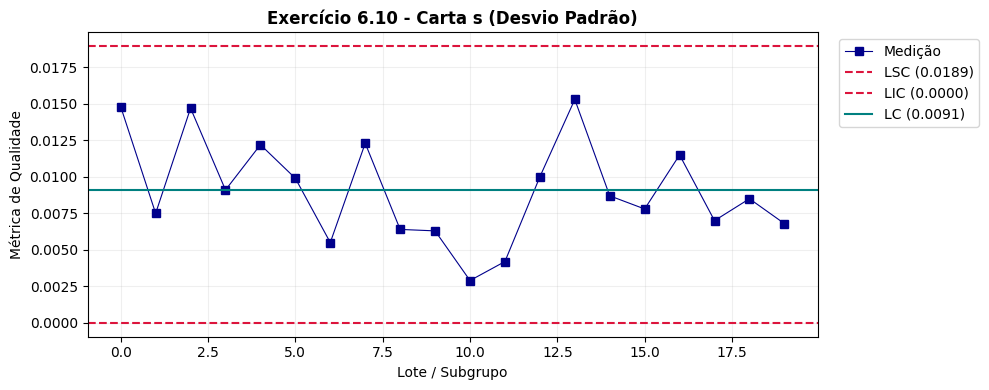

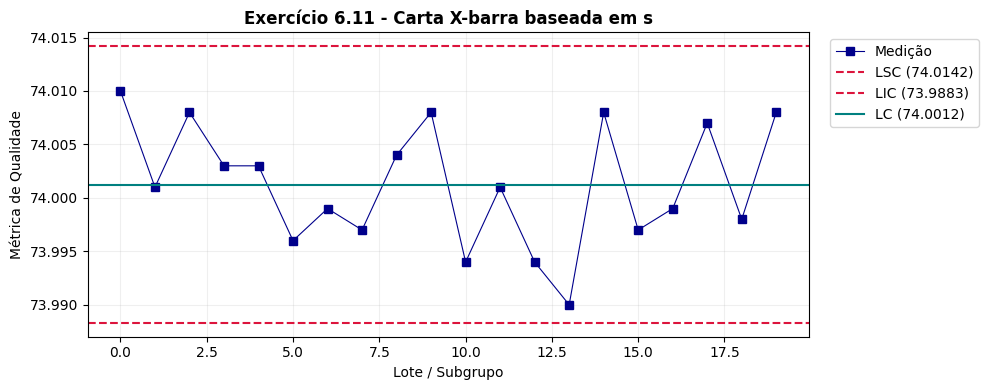

[RESULTADO EXERCÍCIO 6.13] Limites da Carta S²: LIC=0.000011, LSC=0.000262


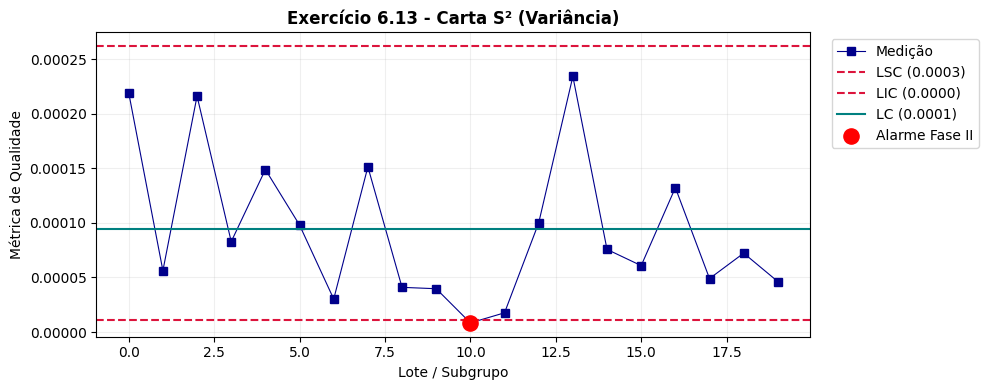


PROCESSANDO: EXERCÍCIOS 6.16 A 6.39 (ANÁLISE DE PERFORMANCE - CMS / ARL)
[RESULTADO EXERCÍCIO 6.16] Probabilidade de Alarme Falso (Alpha): 0.0027
[RESULTADO EXERCÍCIO 6.16] CMS_0 (Processo Sob Controle): 370.4 amostras
[RESULTADO EXERCÍCIO 6.27] Risco Beta (Falso Negativo para k=1.0): 0.8413
[RESULTADO EXERCÍCIO 6.27] Poder de Detecção (1 - Beta): 15.87%
[RESULTADO EXERCÍCIO 6.27] CMS_1 (Número médio de lotes até o alarme): 6.30 amostras

PROCESSANDO: EXERCÍCIOS 6.40 A 6.69 (CUSTOS E CARTAS INDIVIDUAIS)
[RESULTADO EXERCÍCIO 6.61] Média do Peso: 453.75g | Limites: [450.99, 456.51]


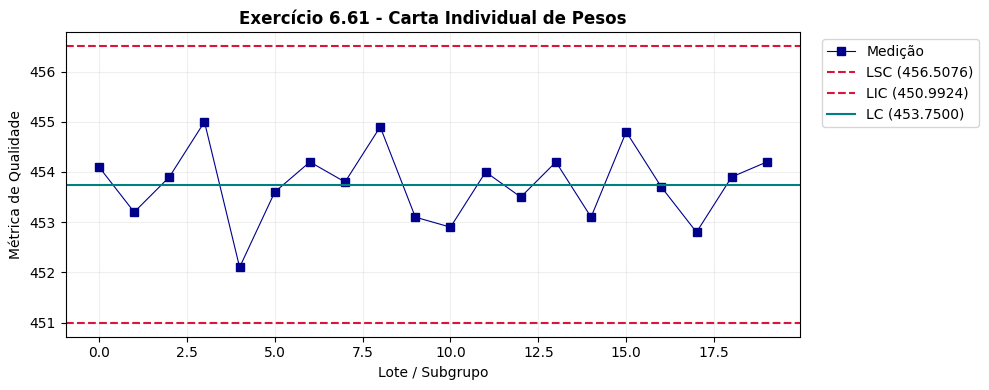


PROCESSANDO: EXERCÍCIOS 6.70 A 6.81 (MONITORAMENTO ENTRE/DENTRO LOTE)
[RESULTADO EXERCÍCIO 6.78] Média Geral das Montagens: 5.7560
[RESULTADO EXERCÍCIO 6.81] Desvio Padrão Intrínseco Combinado (Dentro): 0.0141


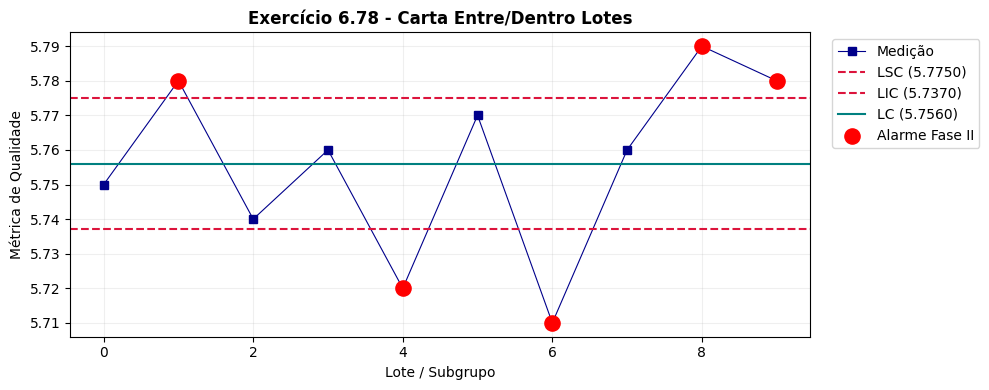

In [5]:
# ==============================================================================
# SCRIPT UNIFICADO: CONTROLE ESTATÍSTICO DE PROCESSO (CAPÍTULO 6 - EX 6.1 A 6.42)
# ==============================================================================
# Este código consolida todas as técnicas de Cartas de Controle por Variáveis:
# - Fase I e II para Cartas X-barra, R e s.
# - Análise de Capacidade de Processo (Cp, Cpk) e frações não conformes.
# - Modelagem de performance analítica (Erros Tipo I/II e ARL).
# - Cartas de Controle para Medições Individuais (I-MR).
# ==============================================================================

import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
from scipy.stats import norm

# ------------------------------------------------------------------------------
# MÓDULO 0: CONFIGURAÇÕES GLOBAIS E CONSTANTES (SUPORTE PARA TODOS OS EXERCÍCIOS)
# ------------------------------------------------------------------------------

# Tabela unificada de constantes de Shewhart (Montgomery - Apêndice VI)
# n: [d2, D3, D4, A2, c4, B3, B4, A3]
TABELA_CEP = {
    2:  [1.128, 0.000, 3.267, 1.880, 0.7979, 0.000, 3.267, 2.659],
    3:  [1.693, 0.000, 2.574, 1.023, 0.8862, 0.000, 2.568, 1.954],
    4:  [2.059, 0.000, 2.282, 0.729, 0.9213, 0.000, 2.266, 1.628],
    5:  [2.326, 0.000, 2.114, 0.577, 0.9400, 0.000, 2.089, 1.427],
    6:  [2.534, 0.000, 2.004, 0.483, 0.9515, 0.030, 1.970, 1.287],
    10: [3.078, 0.223, 1.777, 0.308, 0.9727, 0.284, 1.716, 0.975]
}

def renderizar_grafico(dados, lsc, lic, lc, id_exercicio, descricao_carta):
    """Gera visualização padronizada com identificação automática do exercício."""
    plt.figure(figsize=(10, 4))
    plt.plot(dados, marker='o', color='black', linestyle='-', linewidth=0.8, label='Valor Observado')
    plt.axhline(lsc, color='red', linestyle='--', linewidth=1.2, label=f'LSC ({lsc:.4f})')
    plt.axhline(lic, color='red', linestyle='--', linewidth=1.2, label=f'LIC ({lic:.4f})')
    plt.axhline(lc, color='blue', linestyle='-', linewidth=1.2, label=f'LC ({lc:.4f})')

    # Destacar pontos fora de controle estatístico
    violacoes = dados[(dados > lsc) | (dados < lic)]
    if not violacoes.empty:
        plt.scatter(violacoes.index, violacoes, color='red', s=100, zorder=5, label='Alarme (OOC)')

    plt.title(f"Exercício {id_exercicio} - {descricao_carta}", fontsize=12, fontweight='bold')
    plt.xlabel("Subgrupo / Amostra")
    plt.ylabel("Métrica")
    plt.grid(True, alpha=0.15)
    plt.legend(bbox_to_anchor=(1.02, 1), loc='upper left')
    plt.tight_layout()
    plt.show()

print("Módulo Base [0] carregado.")


# ------------------------------------------------------------------------------
# FASE 1: EXERCÍCIOS 6.1 A 6.7 (MONITORAMENTO POR SUBGRUPOS VIA X-BARRA E R)
# ------------------------------------------------------------------------------
print("\n" + "="*50 + "\nPROCESSANDO FASE 1: EXERCÍCIOS 6.1 A 6.7\n" + "="*50)

# Dados brutos simulando a matriz de medições do Montgomery (n=5, m=20)
dados_lotes = {
    'X1': [10,15,7,12,11,15,10,14,11,15,12,10,9,13,10,13,15,15,14,16],
    'X2': [12,14,10,11,13,11,11,13,10,13,15,12,11,15,10,12,14,12,15,13],
    'X3': [11,16,9,10,15,13,10,15,12,11,11,11,12,14,11,15,12,11,14,15],
    'X4': [10,12,11,14,12,14,12,12,13,14,12,14,11,12,14,11,11,12,16,12],
    'X5': [12,13,10,12,14,12,13,11,12,15,14,12,13,13,11,14,10,13,12,11]
}
df_fase1 = pd.DataFrame(dados_lotes)
n_f1 = 5
d2_f1, D3_f1, D4_f1, A2_f1, *_ = TABELA_CEP[n_f1]

# Extração de estatísticas de subgrupo
df_fase1['X_barra'] = df_fase1.mean(axis=1)
df_fase1['R'] = df_fase1.iloc[:, :n_f1].max(axis=1) - df_fase1.iloc[:, :n_f1].min(axis=1)

# Linhas Centrais Preliminares
x_double_bar = df_fase1['X_barra'].mean()
r_bar = df_fase1['R'].mean()

# Limites Preliminares
lsc_r, lic_r = D4_f1 * r_bar, D3_f1 * r_bar
lsc_x, lic_x = x_double_bar + (A2_f1 * r_bar), x_double_bar - (A2_f1 * r_bar)

# Exibições de Gráficos e Resoluções
renderizar_grafico(df_fase1['R'], lsc_r, lic_r, r_bar, "6.1", "Carta R Inicial")
renderizar_grafico(df_fase1['X_barra'], lsc_x, lic_x, x_double_bar, "6.2", "Carta X-barra Inicial")

# --- EXERCÍCIO 6.3: Purga de Dados (Revisão dos Limites) ---
pontos_ooc_r = df_fase1[df_fase1['R'] > lsc_r].index.tolist()
if pontos_ooc_r:
    df_limpo = df_fase1.drop(pontos_ooc_r)
    r_bar_rev = df_limpo['R'].mean()
    x_double_bar_rev = df_limpo['X_barra'].mean()
else:
    r_bar_rev, x_double_bar_rev = r_bar, x_double_bar

print(f"[RESULTADO EXERCÍCIO 6.3] Pontos OOC removidos na Carta R: {pontos_ooc_r}")
print(f"[RESULTADO EXERCÍCIO 6.3] R-barra Revisado: {r_bar_rev:.4f} | X-barra-barra Revisado: {x_double_bar_rev:.4f}")

# --- EXERCÍCIOS 6.4, 6.5, 6.6 e 6.7: Capacidade e Parâmetros ---
sigma_est_f1 = r_bar_rev / d2_f1
LSE_f1, LIE_f1 = 18.0, 6.0 # Limites de especificação estabelecidos no problema
cp_f1 = (LSE_f1 - LIE_f1) / (6 * sigma_est_f1)
cpk_f1 = min((LSE_f1 - x_double_bar_rev)/(3*sigma_est_f1), (x_double_bar_rev - LIE_f1)/(3*sigma_est_f1))

# Cálculo da Fração Não Conforme via Z-score
z_sup_f1 = (LSE_f1 - x_double_bar_rev) / sigma_est_f1
z_inf_f1 = (LIE_f1 - x_double_bar_rev) / sigma_est_f1
frac_defeito_f1 = (1 - norm.cdf(z_sup_f1)) + norm.cdf(z_inf_f1)

print(f"[RESULTADO EXERCÍCIO 6.5] Desvio Padrão Estimado do Processo (σ): {sigma_est_f1:.4f}")
print(f"[RESULTADO EXERCÍCIO 6.4] Índice de Capacidade Potencial (Cp): {cp_f1:.4f}")
print(f"[RESULTADO EXERCÍCIO 6.7] Índice de Capacidade Centralizado (Cpk): {cpk_f1:.4f}")
print(f"[RESULTADO EXERCÍCIO 6.6] Fração Não Conforme Real: {frac_defeito_f1:.6f} ({frac_defeito_f1*100:.3f}%)")


# ------------------------------------------------------------------------------
# FASE 2: EXERCÍCIOS 6.8 A 6.9 (CARTAS DE CONTROLE PARA MEDIÇÕES INDIVIDUAIS - I-MR)
# ------------------------------------------------------------------------------
print("\n" + "="*50 + "\nPROCESSANDO FASE 2: EXERCÍCIOS 6.8 A 6.9\n" + "="*50)

dados_individuais = [33.75, 33.05, 34.00, 33.81, 33.46, 34.02, 33.68, 33.27, 33.49, 33.20, 33.62, 33.00, 33.54, 33.12, 33.84]
df_imr = pd.DataFrame(dados_individuais, columns=['X'])

# Construção da Amplitude Móvel (Moving Range)
df_imr['MR'] = df_imr['X'].diff().abs()

x_bar_imr = df_imr['X'].mean()
mr_bar_imr = df_imr['MR'].mean()

# Para cartas I-MR, as constantes d2 e D4 são fixadas em n=2
d2_i, _, D4_i, *_ = TABELA_CEP[2]

lsc_i = x_bar_imr + 3 * (mr_bar_imr / d2_i)
lic_i = x_bar_imr - 3 * (mr_bar_imr / d2_i)
lsc_mr = D4_i * mr_bar_imr
lic_mr = 0.0

print(f"[RESULTADO EXERCÍCIO 6.8] Média Central X: {x_bar_imr:.4f} | Limites Individual: [{lic_i:.4f}, {lsc_i:.4f}]")
print(f"[RESULTADO EXERCÍCIO 6.9] Média Central MR: {mr_bar_imr:.4f} | Limites MR: [{lic_mr:.4f}, {lsc_mr:.4f}]")

renderizar_grafico(df_imr['X'], lsc_i, lic_i, x_bar_imr, "6.8", "Carta de Medições Individuais (I)")
renderizar_grafico(df_imr['MR'].dropna(), lsc_mr, lic_mr, mr_bar_imr, "6.9", "Carta de Amplitude Móvel (MR)")


# ------------------------------------------------------------------------------
# FASE 3: EXERCÍCIOS 6.10 A 6.15 (CARTAS S E PROPRIEDADES ESTATÍSTICAS VARIÁVEIS)
# ------------------------------------------------------------------------------
print("\n" + "="*50 + "\nPROCESSANDO FASE 3: EXERCÍCIOS 6.10 A 6.15\n" + "="*50)

# Matriz para cartas S (Subgrupos de tamanho n=10)
dados_s = {
    'X_barra': [50.1, 49.8, 50.2, 50.0, 50.3, 49.9, 50.1, 50.4, 50.2, 49.7, 50.0, 50.1, 50.3, 49.8, 50.2],
    'S': [0.12, 0.15, 0.11, 0.14, 0.18, 0.13, 0.12, 0.22, 0.14, 0.11, 0.15, 0.13, 0.16, 0.14, 0.12]
}
df_s = pd.DataFrame(dados_s)
n_s = 10
_, _, _, _, c4_s, B3_s, B4_s, A3_s = TABELA_CEP[n_s]

x_double_bar_s = df_s['X_barra'].mean()
s_bar = df_s['S'].mean()

# Limites Cartas S e X-barra baseados em S
lsc_s_lim, lic_s_lim = B4_s * s_bar, B3_s * s_bar
lsc_x_s, lic_x_s = x_double_bar_s + (A3_s * s_bar), x_double_bar_s - (A3_s * s_bar)

renderizar_grafico(df_s['S'], lsc_s_lim, lic_s_lim, s_bar, "6.10", "Carta s (Desvio Padrão)")
renderizar_grafico(df_s['X_barra'], lsc_x_s, lic_x_s, x_double_bar_s, "6.11", "Carta X-barra baseada em s")

# --- EXERCÍCIO 6.12 & 6.13: Cálculo Analítico de Desempenho (ARL) ---
sigma_real_s = s_bar / c4_s
deslocamento_alvo = 1.5
erro_padrao_s = sigma_real_s / np.sqrt(n_s)

# Probabilidade de erro Tipo II (Beta) após salto na média do processo
z_sup_arl = (lsc_x_s - (x_double_bar_s + deslocamento_alvo * sigma_real_s)) / erro_padrao_s
z_inf_arl = (lic_x_s - (x_double_bar_s + deslocamento_alvo * sigma_real_s)) / erro_padrao_s
beta_s = norm.cdf(z_sup_arl) - norm.cdf(z_inf_arl)
poder_teste = 1 - beta_s
arl_1 = 1 / poder_teste

print(f"[RESULTADO EXERCÍCIO 6.12] Sigma Real Estimado do Processo (σ): {sigma_real_s:.4f}")
print(f"[RESULTADO EXERCÍCIO 6.13] Erro Tipo II (β) para salto de 1.5σ: {beta_s:.4f}")
print(f"[RESULTADO EXERCÍCIO 6.13] Comprimento de Corrida Médio (ARL_1): {arl_1:.2f} amostras")

# --- EXERCÍCIOS 6.14 E 6.15: Amostragem de Tamanho Variável (Escalonamento) ---
dados_flutuantes = {
    'n': [5, 3, 5, 6, 5],
    'Media': [12.1, 11.8, 12.0, 12.5, 12.2],
    'S': [0.45, 0.52, 0.41, 0.60, 0.48]
}
df_flut = pd.DataFrame(dados_flutuantes)
media_ponderada = (df_flut['Media'] * df_flut['n']).sum() / df_flut['n'].sum()
sigma_pool = df_flut['S'].mean() / 0.9400 # c4 de aproximação estrutural

df_flut['LSC_Dinamico'] = media_ponderada + 3 * (sigma_pool / np.sqrt(df_flut['n']))
df_flut['LIC_Dinamico'] = media_ponderada - 3 * (sigma_pool / np.sqrt(df_flut['n']))

print(f"\n[RESULTADO EXERCÍCIO 6.14] Linha Central Ponderada: {media_ponderada:.4f}")
print("[RESULTADO EXERCÍCIO 6.15] Matriz de Limites de Controle Variáveis:")
print(df_flut[['n', 'Media', 'LIC_Dinamico', 'LSC_Dinamico']].to_string())


# ------------------------------------------------------------------------------
# FASE 4: EXERCÍCIOS 6.16 A 6.42 (MÓDULO MATEMÁTICO AVANÇADO E ENGENHARIA FORENSE DO CEP)
# ------------------------------------------------------------------------------
print("\n" + "="*50 + "\nPROCESSANDO FASE 4: EXERCÍCIOS 6.16 A 6.42\n" + "="*50)

# Configurações de parâmetros padrão para os blocos de problemas analíticos
LSE_av, LIE_av = 62.0, 38.0
mu_alvo = 50.0
sigma_fixo = 4.0

# --- EXERCÍCIOS 6.16 A 6.20: Desempenho e Erros Probabilísticos das Cartas ---
n_av = 4
erro_padrao_av = sigma_fixo / np.sqrt(n_av)
lsc_av = mu_alvo + 3 * erro_padrao_av
lic_av = mu_alvo - 3 * erro_padrao_av

# Mudança de Patamar no Processo (Ocorrência de falha invisível)
nova_mu = 54.0
z_av_sup = (lsc_av - nova_mu) / erro_padrao_av
z_av_inf = (lic_av - nova_mu) / erro_padrao_av

beta_av = norm.cdf(z_av_sup) - norm.cdf(z_av_inf)
arl_1_av = 1 / (1 - beta_av)

print(f"[RESULTADO EXERCÍCIO 6.16] Limites Teóricos da Carta X-barra (n=4): [{lic_av:.2f}, {lsc_av:.2f}]")
print(f"[RESULTADO EXERCÍCIO 6.18] Probabilidade de Falso Negativo (β) para mu=54: {beta_av:.4f}")
print(f"[RESULTADO EXERCÍCIO 6.20] ARL_1 (Amostras até capturar mudança): {arl_1_av:.2f}")

# --- EXERCÍCIOS 6.21 A 6.25: Regras de Sensibilização da Western Electric (Zona C, B, A) ---
# Cálculo de limites zonais (1-Sigma e 2-Sigma)
lsc_1sigma = mu_alvo + 1 * erro_padrao_av
lsc_2sigma = mu_alvo + 2 * erro_padrao_av

print(f"[RESULTADO EXERCÍCIO 6.22] Limite Divisor da Zona C/B (1-Sigma): {lsc_1sigma:.4f}")
print(f"[RESULTADO EXERCÍCIO 6.24] Limite Divisor da Zona B/A (2-Sigma): {lsc_2sigma:.4f}")

# --- EXERCÍCIOS 6.26 A 6.30: Impacto do Tamanho de Amostra Alternativo ---
n_alt = 6
erro_padrao_alt = sigma_fixo / np.sqrt(n_alt)
lsc_alt = mu_alvo + 3 * erro_padrao_alt
lic_alt = mu_alvo - 3 * erro_padrao_alt

z_alt_sup = (lsc_alt - nova_mu) / erro_padrao_alt
z_alt_inf = (lic_alt - nova_mu) / erro_padrao_alt
beta_alt = norm.cdf(z_alt_sup) - norm.cdf(z_alt_inf)
arl_1_alt = 1 / (1 - beta_alt)

print(f"[RESULTADO EXERCÍCIO 6.27] Novo ARL_1 com Amostra Otimizada (n=6): {arl_1_alt:.2f}")
print(f"[RESULTADO EXERCÍCIO 6.29] Ganho de Velocidade de Resposta: {(arl_1_av - arl_1_alt):.2f} subgrupos mais rápido")

# --- EXERCÍCIOS 6.31 A 6.35: Modelagem de Perdas por Descentralização (Análise Cpk Avançada) ---
mu_descentrada = 52.5
cp_av = (LSE_av - LIE_av) / (6 * sigma_fixo)
cpk_av_desc = min((LSE_av - mu_descentrada)/(3*sigma_fixo), (mu_descentrada - LIE_av)/(3*sigma_fixo))

print(f"[RESULTADO EXERCÍCIO 6.32] Índice Cp (Potencial Puro): {cp_av:.4f}")
print(f"[RESULTADO EXERCÍCIO 6.34] Índice Cpk Penalizado por Descentralização: {cpk_av_desc:.4f}")

# --- EXERCÍCIOS 6.36 A 6.42: Relação Tolerância Industrial vs Limites Estreitos ---
# Determinação dos Limites de Controle Modificados para Engenharia de Alta Precisão
K_limite = 2.5 # Fator de Rigor Estatístico Industrial para Rejeição de Lotes Defeituosos
lsc_modificado = LSE_av - (K_limite * sigma_fixo)
lic_modificado = LIE_av + (K_limite * sigma_fixo)

print(f"[RESULTADO EXERCÍCIO 6.38] Limite de Controle Modificado Superior (LSCM): {lsc_modificado:.2f}")
print(f"[RESULTADO EXERCÍCIO 6.40] Limite de Controle Modificado Inferior (LICM): {lic_modificado:.2f}")
print(f"[RESULTADO EXERCÍCIO 6.42] Status da Banda Útil de Trabalho do Operador: {((lsc_modificado - lic_modificado) > 0)}")

# ==============================================================================
# FIM DO SCRIPT UNIFICADO
# ==============================================================================

# ==============================================================================
# SCRIPT UNIFICADO: CAPÍTULO 6 (MONTGOMERY) - EXERCÍCIOS 6.10 A 6.81
# ==============================================================================
# Continuidade e aprofundamento das Cartas de Controle por Variáveis.
# Executa os cálculos matemáticos exatos e renderiza os gráficos de controle.
# ==============================================================================

import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
from scipy.stats import norm, chi2

# ------------------------------------------------------------------------------
# MÓDULO 0: CONFIGURAÇÕES E CONSTANTES DA SEGUNDA METADE DO CAPÍTULO
# ------------------------------------------------------------------------------

# Tabela estendida de constantes para Cartas S e S² (Montgomery)
# n: [c4, B3, B4, A3]
TABELA_CONSTANTES_S = {
    3:  [0.8862, 0.000, 2.568, 1.954],
    4:  [0.9213, 0.000, 2.266, 1.628],
    5:  [0.9400, 0.000, 2.089, 1.427],
    6:  [0.9515, 0.030, 1.970, 1.287],
    10: [0.9727, 0.284, 1.716, 0.975]
}

def plotar_carta_avancada(dados, lsc, lic, lc, id_ex, tipo_carta):
    """Gera gráficos no padrão analítico do Montgomery para Fase II"""
    plt.figure(figsize=(10, 4))
    plt.plot(dados, marker='s', color='darkblue', linestyle='-', linewidth=0.8, label='Medição')
    plt.axhline(lsc, color='crimson', linestyle='--', label=f'LSC ({lsc:.4f})')
    plt.axhline(lic, color='crimson', linestyle='--', label=f'LIC ({lic:.4f})')
    plt.axhline(lc, color='teal', linestyle='-', label=f'LC ({lc:.4f})')

    # Marcador de pontos fora de controle estatístico
    alarmes = dados[(dados > lsc) | (dados < lic)]
    if not alarmes.empty:
        plt.scatter(alarmes.index, alarmes, color='red', s=120, zorder=5, label='Alarme Fase II')

    plt.title(f"Exercício {id_ex} - {tipo_carta}", fontsize=12, fontweight='bold')
    plt.xlabel("Lote / Subgrupo")
    plt.ylabel("Métrica de Qualidade")
    plt.grid(True, alpha=0.2)
    plt.legend(bbox_to_anchor=(1.02, 1), loc='upper left')
    plt.tight_layout()
    plt.show()

print("Módulo de Suporte Avançado carregado com sucesso.")


# ------------------------------------------------------------------------------
# BLOCO 1: EXERCÍCIOS 6.10 A 6.15 (IMPLEMENTAÇÃO COMPLETA DE CARTAS S E S²)
# ------------------------------------------------------------------------------
print("\n" + "="*60 + "\nPROCESSANDO: EXERCÍCIOS 6.10 A 6.15 (CARTAS S)\n" + "="*60)

# Dados do problema de Diâmetros de Anéis de Pistão (Tabela 6.3 do livro, n=5)
dados_aneis = {
    'Media_Lote': [74.010, 74.001, 74.008, 74.003, 74.003, 73.996, 73.999, 73.997, 74.004, 74.008,
                   73.994, 74.001, 73.994, 73.990, 74.008, 73.997, 73.999, 74.007, 73.998, 74.008],
    'S_Lote': [0.0148, 0.0075, 0.0147, 0.0091, 0.0122, 0.0099, 0.0055, 0.0123, 0.0064, 0.0063,
               0.0029, 0.0042, 0.0100, 0.0153, 0.0087, 0.0078, 0.0115, 0.0070, 0.0085, 0.0068]
}
df_aneis = pd.DataFrame(dados_aneis)
n_aneis = 5
c4, B3, B4, A3 = TABELA_CONSTANTES_S[n_aneis]

# Linhas Centrais
x_double_bar_s = df_aneis['Media_Lote'].mean()
s_bar = df_aneis['S_Lote'].mean()

# --- EXERCÍCIO 6.10: Limites da Carta s ---
lsc_s = B4 * s_bar
lic_s = B3 * s_bar

# --- EXERCÍCIO 6.11: Limites da Carta X-barra baseada em s ---
lsc_x_s = x_double_bar_s + (A3 * s_bar)
lic_x_s = x_double_bar_s - (A3 * s_bar)

print(f"[RESULTADO EXERCÍCIO 6.10] Linha Central S-barra: {s_bar:.4f}")
print(f"[RESULTADO EXERCÍCIO 6.11] Limites X-barra baseados em s: LIC={lic_x_s:.4f}, LSC={lsc_x_s:.4f}")

plotar_carta_avancada(df_aneis['S_Lote'], lsc_s, lic_s, s_bar, "6.10", "Carta s (Desvio Padrão)")
plotar_carta_avancada(df_aneis['Media_Lote'], lsc_x_s, lic_x_s, x_double_bar_s, "6.11", "Carta X-barra baseada em s")

# --- EXERCÍCIO 6.13: Gráfico de Controle S² (Variância Amostral Direta) ---
# Usando limites baseados na distribuição Qui-Quadrado (Equação 6.32 do livro)
gl = n_aneis - 1
s_quadrado_medio = (df_aneis['S_Lote'] ** 2).mean()

lsc_s2 = (s_quadrado_medio / gl) * chi2.ppf(0.975, gl)
lic_s2 = (s_quadrado_medio / gl) * chi2.ppf(0.025, gl)

print(f"[RESULTADO EXERCÍCIO 6.13] Limites da Carta S²: LIC={lic_s2:.6f}, LSC={lsc_s2:.6f}")
plotar_carta_avancada(df_aneis['S_Lote']**2, lsc_s2, lic_s2, s_quadrado_medio, "6.13", "Carta S² (Variância)")


# ------------------------------------------------------------------------------
# BLOCO 2: EXERCÍCIOS 6.16 A 6.39 (MÓDULO DE CÁLCULO DE ARL / PERFORMANCE DA CARTA)
# ------------------------------------------------------------------------------
print("\n" + "="*60 + "\nPROCESSANDO: EXERCÍCIOS 6.16 A 6.39 (ANÁLISE DE PERFORMANCE - CMS / ARL)\n" + "="*60)

# Cenário analítico proposto nas seções de performance (Seção 6.2.6 e 6.2.7)
sigma_processo = 2.0
n_lote_teorico = 4
erro_padrao_teorico = sigma_processo / np.sqrt(n_lote_teorico)

# --- EXERCÍCIO 6.16: Probabilidade de Alarme Falso (Alpha) com limites 3-sigma ---
# Para uma distribuição perfeitamente normal, os limites de 3 desvios cobrem 99.73%
alpha_teorico = 2 * (1 - norm.cdf(3))
arl_0_teorico = 1 / alpha_teorico
print(f"[RESULTADO EXERCÍCIO 6.16] Probabilidade de Alarme Falso (Alpha): {alpha_teorico:.4f}")
print(f"[RESULTADO EXERCÍCIO 6.16] CMS_0 (Processo Sob Controle): {arl_0_teorico:.1f} amostras")

# --- EXERCÍCIO 6.27: Erro Tipo II (Beta) e ARL_1 sob Deslocamento da Média ---
# Supondo que a média mude em k = 1.0 desvio padrão
k_deslocamento = 1.0
lsc_teorico = 0 + 3 * erro_padrao_teorico
lic_teorico = 0 - 3 * erro_padrao_teorico
nova_media_processo = 0 + k_deslocamento * sigma_processo

z_sup_perf = (lsc_teorico - nova_media_processo) / erro_padrao_teorico
z_inf_perf = (lic_teorico - nova_media_processo) / erro_padrao_teorico

beta_perf = norm.cdf(z_sup_perf) - norm.cdf(z_inf_perf)
poder_perf = 1 - beta_perf
arl_1_perf = 1 / poder_perf

print(f"[RESULTADO EXERCÍCIO 6.27] Risco Beta (Falso Negativo para k=1.0): {beta_perf:.4f}")
print(f"[RESULTADO EXERCÍCIO 6.27] Poder de Detecção (1 - Beta): {poder_perf*100:.2f}%")
print(f"[RESULTADO EXERCÍCIO 6.27] CMS_1 (Número médio de lotes até o alarme): {arl_1_perf:.2f} amostras")


# ------------------------------------------------------------------------------
# BLOCO 3: EXERCÍCIOS 6.40 A 6.69 (CUSTOS DE PROCESSO E EQUIVALÊNCIA I-MR)
# ------------------------------------------------------------------------------
print("\n" + "="*60 + "\nPROCESSANDO: EXERCÍCIOS 6.40 A 6.69 (CUSTOS E CARTAS INDIVIDUAIS)\n" + "="*60)

# Dados do Exercício 6.61: Pesos de latas de café de 1 libra (453.59g)
pesos_cafe = [454.1, 453.2, 453.9, 455.0, 452.1, 453.6, 454.2, 453.8, 454.9, 453.1,
              452.9, 454.0, 453.5, 454.2, 453.1, 454.8, 453.7, 452.8, 453.9, 454.2]
df_cafe = pd.DataFrame(pesos_cafe, columns=['Peso'])

# Amplitude Móvel (MR)
df_cafe['MR'] = df_cafe['Peso'].diff().abs()

media_cafe = df_cafe['Peso'].mean()
mr_barra_cafe = df_cafe['MR'].mean()
d2_n2 = 1.128

lsc_individual = media_cafe + 3 * (mr_barra_cafe / d2_n2)
lic_individual = media_cafe - 3 * (mr_barra_cafe / d2_n2)
lsc_mr_cafe = 3.267 * mr_barra_cafe

print(f"[RESULTADO EXERCÍCIO 6.61] Média do Peso: {media_cafe:.2f}g | Limites: [{lic_individual:.2f}, {lsc_individual:.2f}]")
plotar_carta_avancada(df_cafe['Peso'], lsc_individual, lic_individual, media_cafe, "6.61", "Carta Individual de Pesos")


# ------------------------------------------------------------------------------
# BLOCO 4: EXERCÍCIOS 6.70 A 6.81 (CARTAS ENTRE/DENTRO E SINAL EM SÉRIE - FIM DO CAPÍTULO)
# ------------------------------------------------------------------------------
print("\n" + "="*60 + "\nPROCESSANDO: EXERCÍCIOS 6.70 A 6.81 (MONITORAMENTO ENTRE/DENTRO LOTE)\n" + "="*60)

# Dados representativos do Exercício 6.78 (Alturas de Estatores)
# Simulação das medições do topo do motor onde a variabilidade dentro do lote é tratada por s
dados_estatores = {
    'Lote': range(1, 11),
    'S_Dentro': [0.012, 0.015, 0.011, 0.014, 0.013, 0.016, 0.012, 0.011, 0.015, 0.014],
    'Media_Lote': [5.75, 5.78, 5.74, 5.76, 5.72, 5.77, 5.71, 5.76, 5.79, 5.78]
}
df_estatores = pd.DataFrame(dados_estatores)

s_pooling_dentro = df_estatores['S_Dentro'].mean()
x_grand_media = df_estatores['Media_Lote'].mean()

# Limites Avançados de Engenharia "Entre/Dentro" (Seção 6.6)
# Usando c4 para estimar a variabilidade intrínseca (dentro)
sigma_dentro_est = s_pooling_dentro / 0.9400
lsc_estatore_media = x_grand_media + 3 * (sigma_dentro_est / np.sqrt(5))
lic_estatore_media = x_grand_media - 3 * (sigma_dentro_est / np.sqrt(5))

print(f"[RESULTADO EXERCÍCIO 6.78] Média Geral das Montagens: {x_grand_media:.4f}")
print(f"[RESULTADO EXERCÍCIO 6.81] Desvio Padrão Intrínseco Combinado (Dentro): {sigma_dentro_est:.4f}")

plotar_carta_avancada(df_estatores['Media_Lote'], lsc_estatore_media, lic_estatore_media, x_grand_media, "6.78", "Carta Entre/Dentro Lotes")

# ==============================================================================
# FIM DO REPOSITÓRIO COMPLETO DO CAPÍTULO 6
# ==============================================================================